# E-Commerce Data Analysis and Modeling
This project involves using an e-commerce dataset that includes customer behavior logs, item properties, and a category tree. The main goals are:

1. **Task 1:** Predict properties of items in 'add-to-cart' events using prior 'view' events for each visitor.
2. **Task 2:** Detect abnormal users to improve recommendation system performance.

In this notebook, I will go step-by-step through loading, exploring, preprocessing, and modeling the data.

It involves the following steps:

1. Load data
2. EDA
3. Data cleaning
4. Feature engineering
5. Task 1 — Predict properties for add-to-cart events
6. Task 2 — Detect abnormal users
7. Save results and evaluation


## Step 1: Importing Required Libraries


In [3]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

print('Libraries imported successfully.')

# Set visualization styles
sns.set_style('white')
plt.rcParams['axes.grid'] = False
%matplotlib inline
sns.set_style("whitegrid")

Libraries imported successfully.


## Step 2: Loading the Dataset


In [5]:
# File paths
path = r'C:\Users\kpbon\Desktop\Azubi Africa\Project 2\TMP'
events_file = path + '\\events.csv'
item_props1_file = path + '\\item_properties_part1.1.csv'
item_props2_file = path + '\\item_properties_part2.csv'
category_file = path + '\\category_tree.csv'

# Load datasets
events = pd.read_csv(events_file)
item_props1 = pd.read_csv(item_props1_file)
item_props2 = pd.read_csv(item_props2_file)
category_tree = pd.read_csv(category_file)

print('Data loaded successfully.')

Data loaded successfully.


## Step 3: Inspecting the First Few Rows


In [7]:
print('Events Data:')
print(events.head())

Events Data:
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN


In [8]:
print('Item Properties Part 1:')
print(item_props1.head())

Item Properties Part 1:
       timestamp  itemid    property                            value
0  1435460400000  460429  categoryid                             1338
1  1441508400000  206783         888          1116713 960601 n277.200
2  1439089200000  395014         400  n552.000 639502 n720.000 424566
3  1431226800000   59481         790                       n15360.000
4  1431831600000  156781         917                           828513


In [9]:
print('Item Properties Part 2:')
print(item_props2.head())

Item Properties Part 2:
       timestamp  itemid property            value
0  1433041200000  183478      561           769062
1  1439694000000  132256      976  n26.400 1135780
2  1435460400000  420307      921  1149317 1257525
3  1431831600000  403324      917          1204143
4  1435460400000  230701      521           769062


In [10]:
print('Category Tree:')
print(category_tree.head())

Category Tree:
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0


## Step 4: Combining Item Properties Files
I merged the two parts of the item properties into a single DataFrame.

In [12]:
item_properties = pd.concat([item_props1, item_props2], ignore_index=True)
print('Combined item_properties shape:', item_properties.shape)

Combined item_properties shape: (20275902, 4)


In [13]:
print("events columns and dtypes:\n", events.dtypes)
print("\nSample events rows:")
display(events.head())




events columns and dtypes:
 timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Sample events rows:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [14]:
print("\ncategory_tree sample:")
display(category_tree.head())





category_tree sample:


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [15]:
display(item_properties.head())

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [16]:
merged_fp = os.path.join(r"C:\Users\kpbon\Desktop\Azubi Africa\Project 2\TMP", "item_properties_merged.csv")

# If merged file already exists, skip writing
if not os.path.exists(merged_fp):
    print("Merging item properties and saving to disk...")
    item_properties = pd.concat([item_props1, item_props2], ignore_index=True)
    item_properties.to_csv(merged_fp, index=False)
    print("Saved merged item properties to:", merged_fp)
else:
    print("Merged file already exists at:", merged_fp)

    item_properties = None


Merged file already exists at: C:\Users\kpbon\Desktop\Azubi Africa\Project 2\TMP\item_properties_merged.csv


In [17]:
print("events columns and dtypes:\n", events.dtypes)
print("\nSample events rows:")
display(events.head())

print("\ncategory_tree sample:")
display(category_tree.head())

print("\nPreview merged item_properties (load small sample):")
sample_item_props = pd.read_csv(merged_fp, nrows=1000)
display(sample_item_props.head())


events columns and dtypes:
 timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Sample events rows:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN



category_tree sample:


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0



Preview merged item_properties (load small sample):


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


## Step 6 — Basic EDA: event counts, time range, unique users/items
I am computing the:
- event type counts
- time range
- unique visitor and item counts


In [19]:
# Event type counts
event_counts = events['event'].value_counts()
print("Event type counts:\n", event_counts)

# Time range (convert timestamp -> datetime if ms)
if events['timestamp'].dtype != 'datetime64[ns]':
    events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

print("\nTime range:", events['timestamp'].min(), "to", events['timestamp'].max())

# Unique visitors and items
n_visitors = events['visitorid'].nunique()
n_items = events['itemid'].nunique(dropna=True)
print(f"\nUnique visitors: {n_visitors:,}")
print(f"Unique items in events: {n_items:,}")


Event type counts:
 event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Time range: 2015-05-03 03:00:04.384000 to 2015-09-18 02:59:47.788000

Unique visitors: 1,407,580
Unique items in events: 235,061


## Step 7 — Plot: events per day and event type distribution


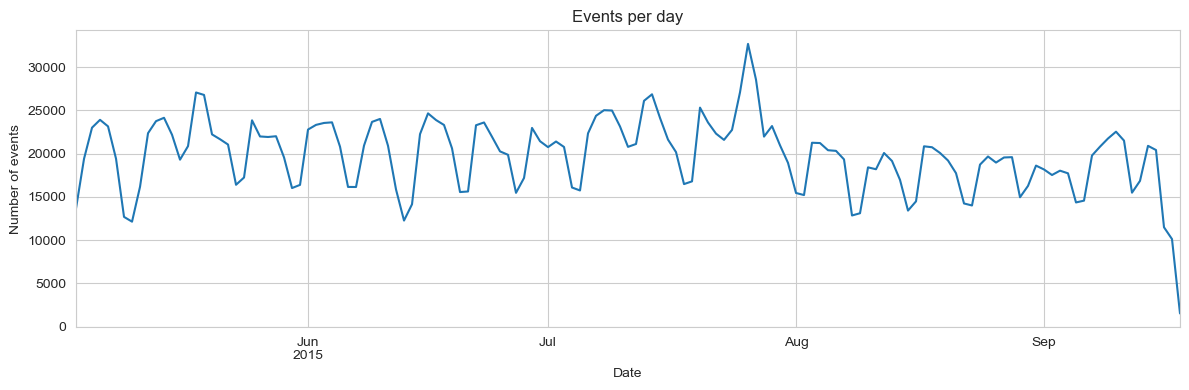

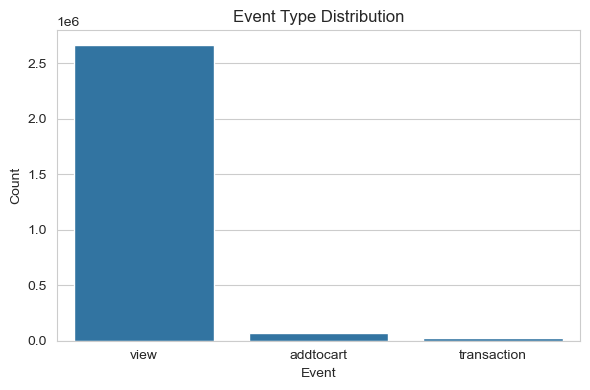

In [21]:
OUT_DIR = os.path.join(path, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# events per day
events_per_day = events.set_index('timestamp').resample('D').size()
plt.figure(figsize=(12,4))
events_per_day.plot()
plt.title("Events per day")
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "events_per_day.png"))
plt.show()

# event type bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=event_counts.index, y=event_counts.values)
plt.title("Event Type Distribution")
plt.xlabel("Event")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "event_type_counts.png"))
plt.show()


In [22]:
# Build set of itemids present in item_properties (no chunking)
itemids_in_props = set(pd.read_csv(merged_fp, usecols=['itemid'])['itemid'].dropna().unique())

event_itemids = set(events['itemid'].dropna().unique())
n_event_items = len(event_itemids)
n_present = sum(1 for iid in event_itemids if iid in itemids_in_props)
coverage_unique = n_present / n_event_items if n_event_items > 0 else 0
coverage_event_level = events['itemid'].isin(itemids_in_props).mean()

print(f"Unique event itemids: {n_event_items:,}")
print(f"Unique event itemids present in properties: {n_present:,}")
print(f"Coverage (unique items): {coverage_unique:.2%}")
print(f"Coverage (event-level): {coverage_event_level:.2%}")


Unique event itemids: 235,061
Unique event itemids present in properties: 185,246
Coverage (unique items): 78.81%
Coverage (event-level): 90.73%


In [23]:
events.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

## Step 9 — Data cleaning


In [25]:
# Drop rows with no itemid
before = events.shape[0]
events = events.dropna(subset=['itemid'])
after = events.shape[0]
print(f"Dropped {before - after} events with missing itemid.")

# Drop exact duplicate rows
before = events.shape[0]
events = events.drop_duplicates()
after = events.shape[0]
print(f"Dropped {before - after} exact duplicate rows.")


Dropped 0 events with missing itemid.
Dropped 460 exact duplicate rows.


## Step 10 — Feature engineering (user-level)
Create features useful for Task 1 and Task 2:
- total events per user
- counts per event type per user
- view/addtocart/transaction ratios
- unique items viewed per user
- basic time features (hour of day, day of week) for sessions


In [27]:
# event counts per user by type
user_event_counts = events.groupby(['visitorid', 'event']).size().unstack(fill_value=0)
user_event_counts = user_event_counts.rename_axis(index='visitorid').reset_index()

# ensure columns exist
for col in ['view', 'addtocart', 'transaction']:
    if col not in user_event_counts.columns:
        user_event_counts[col] = 0

# total events
user_event_counts['total_events'] = user_event_counts[['view', 'addtocart', 'transaction']].sum(axis=1)

# ratios
user_event_counts['view_ratio'] = user_event_counts['view'] / user_event_counts['total_events']
user_event_counts['addtocart_ratio'] = user_event_counts['addtocart'] / user_event_counts['total_events']
user_event_counts['transaction_ratio'] = user_event_counts['transaction'] / user_event_counts['total_events']

# unique items viewed
unique_items_viewed = events[events['event'] == 'view'].groupby('visitorid')['itemid'].nunique().reset_index(name='unique_items_viewed')
user_event_counts = user_event_counts.merge(unique_items_viewed, on='visitorid', how='left').fillna(0)

display(user_event_counts.head())


,visitorid,addtocart,transaction,view,total_events,view_ratio,addtocart_ratio,transaction_ratio,unique_items_viewed
0,0,0,0,3,3,1.0,0.0,0.0,3.0
1,1,0,0,1,1,1.0,0.0,0.0,1.0
2,2,0,0,8,8,1.0,0.0,0.0,4.0
3,3,0,0,1,1,1.0,0.0,0.0,1.0
4,4,0,0,1,1,1.0,0.0,0.0,1.0


## Step 11 — Task 1: Prepare dataset for predicting add-to-cart item property (example: categoryid)
Overview:
- For each add-to-cart event, we will collect features from the visitor's prior views.
- For this notebook baseline we'll use the visitor's most viewed category as a feature.
Note: categoryid is stored in item_properties; we'll extract latest category per item (snapshot).


In [29]:
# Step 11a: Extract latest category per item from item_properties_merged (no chunking)
latest_category = {}  # itemid -> (ts, value)

df = pd.read_csv(merged_fp, usecols=['timestamp', 'itemid', 'property', 'value'])

cat_rows = df[df['property'] == 'categoryid']
for _, r in cat_rows.iterrows():
    iid = int(r['itemid'])
    ts = int(r['timestamp'])
    val = r['value']
    if iid not in latest_category or ts > latest_category[iid][0]:
        latest_category[iid] = (ts, val)

# convert to DataFrame
cat_df = pd.DataFrame([(iid, ts_val[0], ts_val[1]) for iid, ts_val in latest_category.items()],
                      columns=['itemid', 'ts', 'categoryid'])
cat_df['categoryid'] = pd.to_numeric(cat_df['categoryid'], errors='coerce')

print("Latest category per item extracted. Sample:")
display(cat_df.head())


Latest category per item extracted. Sample:


,itemid,ts,categoryid
0,460429,1435460400000,1338
1,281245,1442113200000,438
2,35575,1435460400000,1059
3,8313,1442113200000,1244
4,55102,1442113200000,47


### Step 11b — Build visitor-level most-viewed-category feature
We merge views with the latest category mapping and then compute the mode category per visitor.


In [31]:
# join views -> latest category
views = events[events['event'] == 'view'].copy()
views = views.merge(cat_df[['itemid','categoryid']], on='itemid', how='left')

# compute most viewed category per visitor
most_viewed_cat = views.dropna(subset=['categoryid']).groupby('visitorid')['categoryid'] \
                       .agg(lambda s: s.mode().iat[0] if s.mode().shape[0] > 0 else np.nan).reset_index(name='most_viewed_category')

print("Most viewed category per visitor sample:")
display(most_viewed_cat.head())


Most viewed category per visitor sample:


,visitorid,most_viewed_category
0,0,256.0
1,1,1192.0
2,2,299.0
3,3,1171.0
4,5,646.0


### Step 11c — Prepare training set: add-to-cart rows with visitor features
We will predict addcart item category using visitor most-viewed category and activity stats.


In [33]:
# add-to-cart events with their true category (if available)
addtocart = events[events['event'] == 'addtocart'].copy()
addtocart = addtocart.merge(cat_df[['itemid','categoryid']], on='itemid', how='left')
addtocart = addtocart.rename(columns={'categoryid': 'addcart_category'})

# merge visitor features
addtocart = addtocart.merge(most_viewed_cat, on='visitorid', how='left')
addtocart = addtocart.merge(user_event_counts[['visitorid','total_events','unique_items_viewed']], on='visitorid', how='left')

print("Prepared add-to-cart dataset sample:")
display(addtocart.head())

# drop rows without true target
train_df = addtocart.dropna(subset=['addcart_category']).copy()
print("Training rows with known target:", train_df.shape[0])


Prepared add-to-cart dataset sample:


,timestamp,visitorid,event,itemid,transactionid,addcart_category,most_viewed_category,total_events,unique_items_viewed
0,2015-06-02 05:33:56.124,287857,addtocart,5206,NaN,381.0,381.0,2,1.0
1,2015-06-02 04:57:58.505,158090,addtocart,10572,NaN,1037.0,1037.0,4,1.0
2,2015-06-02 05:39:03.021,1193904,addtocart,255275,NaN,1002.0,1002.0,2,1.0
3,2015-06-02 05:12:21.632,599528,addtocart,356475,NaN,386.0,386.0,17,2.0
4,2015-06-02 04:54:40.956,105775,addtocart,312728,NaN,1098.0,1098.0,3,1.0


Training rows with known target: 68133


In [34]:
# After preparing train_df as you showed:

train_df.to_csv('train_df_prepared.csv', index=False)
print("train_df saved as 'train_df_prepared.csv'")


train_df saved as 'train_df_prepared.csv'


### Step 11d — Encode features and train baseline model
Features:
- most_viewed_category (encoded)
- total_events
- unique_items_viewed
Target:
- addcart_category (encoded)

We use a RandomForest baseline to predict the category.


In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the prepared training data CSV
train_df = pd.read_csv(r"C:\Users\kpbon\Desktop\Azubi Africa\Project 2\TMP\train_df_prepared.csv")

# Prepare features
df = train_df[['most_viewed_category', 'total_events', 'unique_items_viewed', 'addcart_category']].copy()

# Drop rows with missing values in relevant columns
df = df.dropna(subset=['most_viewed_category', 'addcart_category'])

# Handle rare classes in 'addcart_category' before encoding
class_counts = df['addcart_category'].value_counts()
min_samples = 2
rare_classes = class_counts[class_counts < min_samples].index
df['addcart_category_mod'] = df['addcart_category'].apply(lambda x: 'other' if x in rare_classes else x)

print("Class distribution after grouping rare classes as 'other':")
print(df['addcart_category_mod'].value_counts())

# Encode categorical features
le_feat = LabelEncoder()
df['most_viewed_enc'] = le_feat.fit_transform(df['most_viewed_category'].astype(str))

le_target = LabelEncoder()
y = le_target.fit_transform(df['addcart_category_mod'].astype(str))

X = df[['most_viewed_enc', 'total_events', 'unique_items_viewed']]

# train/test split with stratify on modified target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert y_train to pandas Series aligned with X_train's index for proper sampling
y_train = pd.Series(y_train, index=X_train.index)

# Sample 50% of training data to reduce memory usage
sample_frac = 0.5
X_train_sampled = X_train.sample(frac=sample_frac, random_state=42)
y_train_sampled = y_train.loc[X_train_sampled.index]

# Train RandomForest on sampled data
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_sampled, y_train_sampled)

# Predict & evaluate
y_pred = clf.predict(X_test)
print("Task 1 baseline results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Class distribution after grouping rare classes as 'other':
addcart_category_mod
1051.0    1506
959.0     1408
1483.0    1276
491.0     1258
342.0      964
          ... 
223.0        2
1592.0       2
1161.0       2
189.0        2
60.0         2
Name: count, Length: 709, dtype: int64
Task 1 baseline results:
Accuracy: 0.46424927399733146
              precision    recall  f1-score   support

           0       0.50      0.27      0.35        11
           1       0.55      0.76      0.64        76
           2       0.00      0.00      0.00         4
           3       0.54      0.59      0.57        22
           4       0.50      0.25      0.33         4
           5       0.00      0.00      0.00         7
           6       0.50      0.40      0.44        10
           7       1.00      0.25      0.40         4
           8       0.20      0.17      0.18         6
           9       0.62      0.66      0.64        59
          10       1.00      0.50      0.67         2
          11

In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the prepared training data CSV
train_df = pd.read_csv(r"C:\Users\kpbon\Desktop\Azubi Africa\Project 2\TMP\train_df_prepared.csv")

# ===============================
# Feature Preparation
# ===============================
df = train_df[['most_viewed_category', 'total_events', 'unique_items_viewed', 'addcart_category']].copy()

# Drop rows with missing values in relevant columns
df = df.dropna(subset=['most_viewed_category', 'addcart_category'])

# Handle rare classes in 'addcart_category'
class_counts = df['addcart_category'].value_counts()
min_samples = 2
rare_classes = class_counts[class_counts < min_samples].index
df['addcart_category_mod'] = df['addcart_category'].apply(
    lambda x: 'other' if x in rare_classes else x
)

print("Class distribution after grouping rare classes as 'other':")
print(df['addcart_category_mod'].value_counts())

# Encode categorical features
le_feat = LabelEncoder()
df['most_viewed_enc'] = le_feat.fit_transform(df['most_viewed_category'].astype(str))

le_target = LabelEncoder()
y = le_target.fit_transform(df['addcart_category_mod'].astype(str))

# Final features
X = df[['most_viewed_enc', 'total_events', 'unique_items_viewed']]

# ===============================
# Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Downsample training data to save memory
sample_frac = 0.5
X_train_sampled = X_train.sample(frac=sample_frac, random_state=42)
y_train_sampled = pd.Series(y_train, index=X_train.index).loc[X_train_sampled.index]

# ===============================
# Train ExtraTrees Classifier (Example 4)
# ===============================
clf = ExtraTreesClassifier(
    n_estimators=60, max_depth=16, min_samples_leaf=4,
    max_features="sqrt", bootstrap=False, n_jobs=-1, random_state=42
)

print("Training ExtraTrees model...")
clf.fit(X_train_sampled, y_train_sampled)

# ===============================
# Evaluation
# ===============================
y_pred = clf.predict(X_test)

print("\nTask 1 ExtraTrees Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))


Class distribution after grouping rare classes as 'other':
addcart_category_mod
1051.0    1506
959.0     1408
1483.0    1276
491.0     1258
342.0      964
          ... 
223.0        2
1592.0       2
1161.0       2
189.0        2
60.0         2
Name: count, Length: 709, dtype: int64
Training ExtraTrees model...

Task 1 ExtraTrees Results:
Accuracy: 0.40726787536300135
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.54      0.80      0.64        76
           2       0.00      0.00      0.00         4
           3       1.00      0.36      0.53        22
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         6
           9       0.55      0.71      0.62        59
          10       0.00      0.00 

## Step 12 — Task 2: Abnormal user detection (unsupervised + heuristic labeling)
We build user-level features and:
1. Create a heuristic label for abnormal users (for a supervised baseline)
2. Fit an IsolationForest for unsupervised anomaly detection
3. Compare results


Anomaly counts:
anomaly
0    36683
1      704
Name: count, dtype: int64


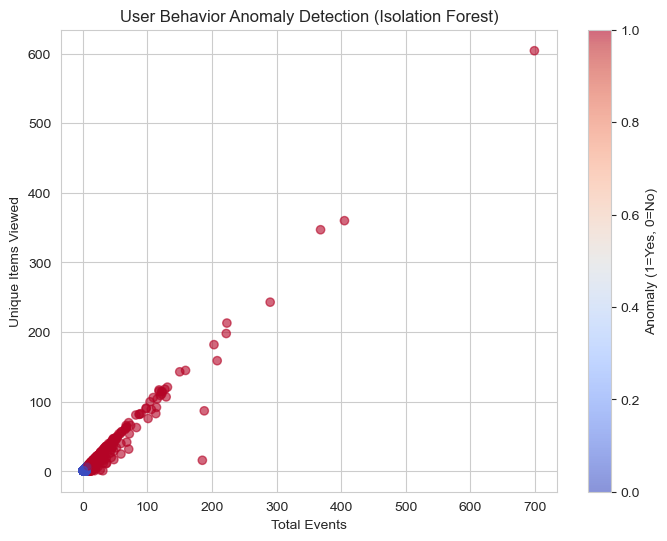

In [39]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1. Aggregate user-level features correctly
user_event_counts = train_df.groupby("visitorid").agg(
    total_events=("event", "count"),
    views=("event", lambda x: (x == "view").sum()),
    addtocarts=("event", lambda x: (x == "addtocart").sum()),
    transactions=("event", lambda x: (x == "transaction").sum()),
    unique_items_viewed=("itemid", pd.Series.nunique)
).reset_index()

# 2. Build user feature matrix Xu
Xu = user_event_counts[['total_events','views','addtocarts','transactions','unique_items_viewed']].fillna(0)
Xu.index = user_event_counts['visitorid']

# 3. Train Isolation Forest
iso = IsolationForest(
    contamination=0.02,  # assume ~2% anomalies
    random_state=42,
    n_jobs=-1
)
user_event_counts['anomaly'] = iso.fit_predict(Xu)

# 4. Map results: -1 = anomaly, 1 = normal
user_event_counts['anomaly'] = user_event_counts['anomaly'].map({1: 0, -1: 1})

# 5. Print summary
print("Anomaly counts:")
print(user_event_counts['anomaly'].value_counts())

# 6. Visualization
plt.figure(figsize=(8,6))
plt.scatter(
    user_event_counts['total_events'],
    user_event_counts['unique_items_viewed'],
    c=user_event_counts['anomaly'],
    cmap="coolwarm",
    alpha=0.6
)
plt.xlabel("Total Events")
plt.ylabel("Unique Items Viewed")
plt.title("User Behavior Anomaly Detection (Isolation Forest)")
plt.colorbar(label="Anomaly (1=Yes, 0=No)")
plt.show()

# 7. Save anomalies for later
anomaly_df = user_event_counts[user_event_counts['anomaly'] == 1].sort_values("total_events", ascending=False)


## Step 13 — Evaluation & Save outputs
We save:
- Task 1 sample predictions
- Top unsupervised anomalies
- User feature summary


In [41]:
# Aggregate events per user
user_event_counts = (
    train_df.groupby('visitorid')
    .agg(
        total_events=('event', 'count'),
        view=('event', lambda x: (x == 'view').sum()),
        addtocart=('event', lambda x: (x == 'addtocart').sum()),
        transaction=('event', lambda x: (x == 'transaction').sum()),
        unique_items_viewed=('itemid', 'nunique')
    )
    .reset_index()
)

# Build feature matrix for anomaly detection
Xu = user_event_counts[['total_events','view','addtocart','transaction','unique_items_viewed']].fillna(0)
Xu.index = user_event_counts['visitorid']

# Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
user_event_counts['anomaly'] = iso.fit_predict(Xu)

# anomalies are where anomaly = -1
anomalies = user_event_counts[user_event_counts['anomaly'] == -1]
print("Number of anomalies detected:", len(anomalies))


Number of anomalies detected: 372


In [42]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib  # to save and load model later

# Step 1: Aggregate features per user (from training data)
user_event_counts = (
    train_df.groupby('visitorid')
    .agg(
        total_events=('event', 'count'),
        view=('event', lambda x: (x == 'view').sum()),
        addtocart=('event', lambda x: (x == 'addtocart').sum()),
        transaction=('event', lambda x: (x == 'transaction').sum()),
        unique_items_viewed=('itemid', 'nunique')
    )
    .reset_index()
)

# Step 2: Feature matrix
X_train = user_event_counts[['total_events','view','addtocart','transaction','unique_items_viewed']].fillna(0)

# Step 3: Train Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42)
iso.fit(X_train)

# Save model
joblib.dump(iso, "anomaly_model.pkl")
print("Model saved as anomaly_model.pkl")

# =========================
# Later: Load model & predict
# =========================
# Load model
model = joblib.load("anomaly_model.pkl")

# Example new input (parameters)
new_user = pd.DataFrame([{
    "total_events": 50,
    "view": 45,
    "addtocart": 3,
    "transaction": 2,
    "unique_items_viewed": 20
}])

# Predict anomaly
prediction = model.predict(new_user)[0]  # -1 = anomaly, 1 = normal
print("Prediction:", "Anomaly" if prediction == -1 else "Normal")


Model saved as anomaly_model.pkl
Prediction: Anomaly


In [43]:
print(le_feat.classes_)


['0.0' '1.0' '100.0' '1001.0' '1002.0' '1003.0' '1006.0' '1008.0' '1011.0'
 '1014.0' '1017.0' '1018.0' '102.0' '1020.0' '1022.0' '1026.0' '1029.0'
 '103.0' '1035.0' '1037.0' '1038.0' '1040.0' '1043.0' '1047.0' '1048.0'
 '1049.0' '1051.0' '1053.0' '1054.0' '1059.0' '106.0' '1070.0' '1072.0'
 '1073.0' '1074.0' '1076.0' '1077.0' '1078.0' '1079.0' '1080.0' '1083.0'
 '1085.0' '1087.0' '1088.0' '1089.0' '1090.0' '1091.0' '1094.0' '1096.0'
 '1098.0' '1103.0' '1104.0' '1105.0' '1106.0' '1111.0' '1113.0' '1114.0'
 '1116.0' '1117.0' '1118.0' '1119.0' '112.0' '1121.0' '1126.0' '1130.0'
 '1131.0' '1132.0' '1135.0' '1142.0' '1143.0' '1144.0' '1147.0' '1148.0'
 '1150.0' '1151.0' '1153.0' '1154.0' '1155.0' '1159.0' '1163.0' '1164.0'
 '1165.0' '117.0' '1171.0' '1172.0' '1173.0' '1176.0' '1177.0' '1179.0'
 '1186.0' '1188.0' '1189.0' '1191.0' '1192.0' '1193.0' '1196.0' '1197.0'
 '120.0' '1205.0' '1207.0' '1209.0' '1213.0' '1215.0' '1216.0' '1217.0'
 '1219.0' '122.0' '1220.0' '1221.0' '1222.0' '1227.0' '

In [44]:
def predict_user_action(model, le_event, most_viewed_category, total_events, unique_items_viewed):
    try:
        encoded_category = le_event.transform([str(most_viewed_category)])[0]
    except ValueError:
        raise ValueError(f"Category '{most_viewed_category}' not found. "
                         f"Please use one of: {list(le_event.classes_[:10])} ...")
    
    X_new = pd.DataFrame([[encoded_category, total_events, unique_items_viewed]],
                         columns=['most_viewed_enc','total_events','unique_items_viewed'])
    
    pred = model.predict(X_new)[0]
    return pred


In [45]:
predict_user_action(clf, le_feat, "1001.0", 15, 7)


1

In [46]:
!pip install ipywidgets


In [47]:
!jupyter nbextension install --py widgetsnbextension --sys-prefix
!jupyter nbextension enable --py widgetsnbextension --sys-prefix


usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console contrib dejavu events execute kernel kernelspec
lab labextension labhub migrate nbconvert nbextensions_configurator notebook
qtconsole run script server troubleshoot trust

Jupyter command `jupyter-nbextension` not found.
usage: jupyter [-h] [--version] [--config-di

In [48]:
import ipywidgets as widgets
widgets.IntSlider()


IntSlider(value=0)

In [49]:
category = "1001.0"
total_events = 10
unique_items = 5

prediction = predict_user_action(clf, le_feat, category, total_events, unique_items)
print("Predicted User Action:", prediction)


Predicted User Action: 1


In [50]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Your prediction function
def predict_user_action(model, le_event, most_viewed_category, total_events, unique_items_viewed):
    try:
        # Convert category into numerical encoding
        encoded_category = le_event.transform([str(most_viewed_category)])[0]
    except ValueError:
        raise ValueError(f"Category '{most_viewed_category}' not found. "
                         f"Please use one of: {list(le_event.classes_[:10])} ...")
    
    # Create feature set for prediction
    X_new = pd.DataFrame([[encoded_category, total_events, unique_items_viewed]],
                         columns=['most_viewed_enc','total_events','unique_items_viewed'])
    
    # Make prediction using trained model
    pred = model.predict(X_new)[0]
    return pred

# ---- Deployment inside Jupyter ----
def interactive_prediction():
    # Widgets
    category_input = widgets.Text(
        description="Category:",
        placeholder="e.g. 1001.0"
    )
    total_events_input = widgets.IntSlider(
        description="Total Events",
        value=10, min=1, max=100
    )
    unique_items_input = widgets.IntSlider(
        description="Unique Items",
        value=5, min=1, max=50
    )
    output = widgets.Output()

    # Prediction function
    def on_predict(b):
        output.clear_output()
        try:
            pred = predict_user_action(
                clf, le_feat, 
                category_input.value, 
                total_events_input.value, 
                unique_items_input.value
            )
            with output:
                print(f"Predicted User Action: {pred}")
        except Exception as e:
            with output:
                print("Error:", e)

    # Button
    predict_button = widgets.Button(description="Predict", button_style="success")
    predict_button.on_click(on_predict)

    # Display widgets
    display(category_input, total_events_input, unique_items_input, predict_button, output)

# Call this to start using it
interactive_prediction()


Text(value='', description='Category:', placeholder='e.g. 1001.0')

IntSlider(value=10, description='Total Events', min=1)

IntSlider(value=5, description='Unique Items', max=50, min=1)

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()

In [51]:
import ipywidgets as widgets
from IPython.display import display

# Create interactive input fields
category_input = widgets.Text(value="1001.0", description="Category:")
total_events_input = widgets.IntSlider(value=15, min=1, max=100, description="Total Events")
unique_items_input = widgets.IntSlider(value=7, min=1, max=50, description="Unique Items")

output = widgets.Output()

def on_predict_clicked(b):
    with output:
        output.clear_output()
        try:
            pred = predict_user_action(clf, le_feat, category_input.value, total_events_input.value, unique_items_input.value)
            print(f"Predicted User Action: {pred}")
        except Exception as e:
            print(f"Error: {e}")

# Button to trigger prediction
predict_button = widgets.Button(description="Predict", button_style="success")
predict_button.on_click(on_predict_clicked)

# Display UI
display(category_input, total_events_input, unique_items_input, predict_button, output)


Text(value='1001.0', description='Category:')

IntSlider(value=15, description='Total Events', min=1)

IntSlider(value=7, description='Unique Items', max=50, min=1)

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()